# Phase 8: Structural Root-Cause Analysis of Persistent Ranking Failures

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from pathlib import Path
from itertools import product
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

warnings.filterwarnings('default')
np.random.seed(36)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

#Paths
PROJECT_ROOT=Path.cwd().parent
DATA_RAW=PROJECT_ROOT / 'data' / 'raw'
PHASE6_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase6_models'
PHASE8_OUTPUT=PROJECT_ROOT / 'data' / 'processed' / 'phase8_structural_analysis'
PHASE8_OUTPUT.mkdir(parents=True, exist_ok=True)

#Config space
MODELS=['pointwise', 'pairwise', 'lightgbm']
PIPELINES=['raw', 'global', 'per_query']
DATASET='2007'
BASELINE_KEY='pointwise_raw_2007'  

#Statistical constants
FDR_ALPHA=0.05
N_BOOTSTRAP=2000
EFFECT_THRESHOLD_CONTINUOUS=0.10
EFFECT_THRESHOLD_CATEGORICAL=0.01
MIN_SAMPLE_WARNING=10

print('='*80)
print('PHASE 8: STRUCTURAL ROOT-CAUSE ANALYSIS')
print('='*80)
print(f'Output directory:{PHASE8_OUTPUT}')
print(f'Baseline config:{BASELINE_KEY}')
print(f'Dataset focus:MQ{DATASET}')
print(f'FDR alpha:{FDR_ALPHA}')
print(f'Effect thresh (cont):{EFFECT_THRESHOLD_CONTINUOUS}')
print(f'Effect thresh (cat):{EFFECT_THRESHOLD_CATEGORICAL}')
print(f'Bootstrap reps:{N_BOOTSTRAP}')
print(f'Min sample warning :{MIN_SAMPLE_WARNING}')
print('='*80)

PHASE 8: STRUCTURAL ROOT-CAUSE ANALYSIS
Output directory:b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase8_structural_analysis
Baseline config:pointwise_raw_2007
Dataset focus:MQ2007
FDR alpha:0.05
Effect thresh (cont):0.1
Effect thresh (cat):0.01
Bootstrap reps:2000
Min sample warning :10


## 2. Utility functions

In [8]:

# 1.failure-flag parser 

def make_fail_flag(series: pd.Series) -> pd.Series:
    #Convert Failure@5_primary to clean 0/1 int. Unknown -> 0 (conservative).
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(0).astype(float).round().astype(int).clip(0, 1)
    _T = {'true', '1', 'yes', '1.0'}
    _F = {'false', '0', 'no', '0.0', ''}
    def _p(v):
        if pd.isna(v): return 0
        if isinstance(v, bool): return int(v)
        if isinstance(v, (int, float)):
            return 0 if np.isnan(float(v)) else int(round(float(v)))
        if isinstance(v, str):
            vl=v.strip().lower()
            if vl in _T: return 1
            if vl in _F: return 0
        return 0
    return series.map(_p).astype(int)

#Self-test
_test = pd.Series([True, False, 'True', 'false', '1', '0', 1.0, 0.0, pd.NA, None])
assert list(make_fail_flag(_test)) == [1, 0, 1, 0, 1, 0, 1, 0, 0, 0], 'make_fail_flag FAILED self-test'
del _test
print('make_fail_flag')


# 2. Cliff's delta 
def cliffs_delta_unpaired(a: np.ndarray, b: np.ndarray) -> float:
    
    a=np.asarray(a, dtype=float)
    b=np.asarray(b, dtype=float)

    #Dropping NaNs (keeps stats stable if caller forgets)
    a=a[~np.isnan(a)]
    b=b[~np.isnan(b)]

    n_a, n_b=len(a), len(b)
    if n_a==0 or n_b==0:
        return 0.0

    a_sorted=np.sort(a)
    b_sorted=np.sort(b)

    #Counting pairs a > b and a < b using two-pointer scans
    greater=0
    j=0
    for i in range(n_a):
        while j < n_b and b_sorted[j] < a_sorted[i]:
            j += 1
        greater += j  # number of b values < a[i]

    less=0
    j=0
    for i in range(n_a):
        while j < n_b and b_sorted[j] <= a_sorted[i]:
            j += 1
        less += (n_b - j)  # number of b values > a[i]

    return float((greater - less) / (n_a * n_b))

print('cliffs_delta_unpaired')



# 3. Bootstrap CI for median difference 

def bootstrap_median_diff(a: np.ndarray, b: np.ndarray, n_boot: int = N_BOOTSTRAP) -> tuple:
    #Bootstrap 95% CI for median(a) - median(b).
    if len(a)==0 or len(b)==0:
        return 0.0, 0.0
    diffs=[]
    for _ in range(n_boot):
        a_sample=a[np.random.randint(0, len(a), len(a))]
        b_sample=b[np.random.randint(0, len(b), len(b))]
        diffs.append(np.median(a_sample) - np.median(b_sample))
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

print('bootstrap_median_diff')



# 4. Bootstrap CI for risk difference 

def bootstrap_risk_diff(a_binary: np.ndarray, b_binary: np.ndarray, n_boot: int = N_BOOTSTRAP) -> tuple:
    #Bootstrap 95% CI for risk_diff=mean(a) - mean(b).
    if len(a_binary)==0 or len(b_binary)==0:
        return 0.0, 0.0
    diffs=[]
    for _ in range(n_boot):
        a_sample=a_binary[np.random.randint(0, len(a_binary), len(a_binary))]
        b_sample=b_binary[np.random.randint(0, len(b_binary), len(b_binary))]
        diffs.append(a_sample.mean()-b_sample.mean())
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

print('bootstrap_risk_diff')



# 5. BH-FDR correction

def bh_fdr(pvals: list, alpha: float = FDR_ALPHA) -> np.ndarray:
    #Benjamini-Hochberg FDR correction.
    pvals=np.asarray(pvals, dtype=float)
    n=len(pvals)
    if n==0:
        return np.array([])
    order=np.argsort(pvals)
    ranks=np.arange(1, n + 1)
    adj=np.minimum(pvals[order] * n / ranks, 1.0)
    adj=np.minimum.accumulate(adj[::-1])[::-1]
    q=np.empty(n)
    q[order]=adj
    return q

print('bh_fdr')



# 6. Alignment safety check 

def check_alignment_or_raise(test_df: pd.DataFrame, pred_df: pd.DataFrame) -> tuple:
    """
    Verify alignment keys exist between test features and predictions.
    Returns (alignment_ok: bool, keys: list).
    """
    #Checking (qid, docid)
    if 'docid' in test_df.columns and 'docid' in pred_df.columns:
        print('Alignment: (qid, docid) present in both')
        #Quick validation
        test_pairs=set(zip(test_df['qid'], test_df['docid']))
        pred_pairs=set(zip(pred_df['qid'], pred_df['docid']))
        if len(test_pairs & pred_pairs) > 0:
            print(f'{len(test_pairs & pred_pairs)} matching (qid,docid) pairs found')
            return True, ['qid', 'docid']
        else:
            print('No matching (qid,docid) pairs -> UNSAFE')
            return False, []
    
    #Checking (qid, doc_idx) with validation
    if 'doc_idx' in test_df.columns and 'doc_idx' in pred_df.columns:
        print('Found (qid, doc_idx) - validating alignment...')
        #Checking per-qid doc counts match
        test_counts=test_df.groupby('qid').size()
        pred_counts=pred_df.groupby('qid').size()
        common_qids=set(test_counts.index) & set(pred_counts.index)
        if len(common_qids)==0:
            print('No common qids -> UNSAFE')
            return False, []
        mismatches=sum(test_counts[q] != pred_counts[q] for q in common_qids if q in test_counts.index and q in pred_counts.index)
        if mismatches > 0:
            print(f'{mismatches} qids have different doc counts -> UNSAFE')
            return False, []
        #Checking if doc_idx are contiguous 0..n-1 per qid
        for qid in list(common_qids)[:5]:  #spot check
            test_idx=sorted(test_df[test_df['qid']==qid]['doc_idx'].values)
            pred_idx=sorted(pred_df[pred_df['qid']==qid]['doc_idx'].values)
            if test_idx != pred_idx or test_idx != list(range(len(test_idx))):
                print(f'doc_idx not contiguous or mismatched for qid={qid} -> UNSAFE')
                return False, []
        print('doc_idx alignment validated')
        return True, ['qid', 'doc_idx']
    
    #No reliable alignment
    print('NO RELIABLE ALIGNMENT KEYS (no docid, no valid doc_idx)')
    print('-> Feature <-> score association SKIPPED')
    return False, []

print('check_alignment_or_raise')

print('\nAll utility functions defined with guards')

make_fail_flag
cliffs_delta_unpaired
bootstrap_median_diff
bootstrap_risk_diff
bh_fdr
check_alignment_or_raise

All utility functions defined with guards


## 3. Loading Phase 6 artifacts

In [9]:
print('='*80)
print('LOADING PHASE 6 ARTIFACTS (MQ2007) WITH VALIDATION')
print('='*80)

all_query_metrics={}
all_predictions={}

for model, pipeline in product(MODELS, PIPELINES):
    key=f'{model}_{pipeline}_{DATASET}'
    
    qm_file=PHASE6_OUTPUT / f'{key}_query_metrics.csv'
    pred_file=PHASE6_OUTPUT / f'{key}_predictions.csv'
    
    #Hard fail if missing
    if not qm_file.exists():
        raise RuntimeError(f'MISSING FILE: {qm_file}')
    if not pred_file.exists():
        raise RuntimeError(f'MISSING FILE: {pred_file}')
    
    qm=pd.read_csv(qm_file)
    pred=pd.read_csv(pred_file)
    
    #Validating required columns
    required_qm=['qid', 'num_docs', 'num_relevant_1', 'Failure@5_primary']
    for col in required_qm:
        if col not in qm.columns:
            raise RuntimeError(f'MISSING COLUMN "{col}" in {qm_file}')
    
    required_pred=['qid', 'label', 'score']
    for col in required_pred:
        if col not in pred.columns:
            raise RuntimeError(f'MISSING COLUMN "{col}" in {pred_file}')
    
    #Parsing failure flag
    qm['_fail_flag']=make_fail_flag(qm['Failure@5_primary'])
    
    all_query_metrics[key]=qm
    all_predictions[key]=pred
    print(f'{key:35s} ({len(qm)} queries, {len(pred)} docs)')

expected=len(MODELS) * len(PIPELINES)
assert len(all_query_metrics)==expected, f'Expected {expected} configs, got {len(all_query_metrics)}'

print(f'\nLoaded {len(all_query_metrics)} / {expected} configs')
print('='*80)

LOADING PHASE 6 ARTIFACTS (MQ2007) WITH VALIDATION
pointwise_raw_2007                  (336 queries, 13652 docs)
pointwise_global_2007               (336 queries, 13652 docs)
pointwise_per_query_2007            (336 queries, 13652 docs)
pairwise_raw_2007                   (336 queries, 13652 docs)
pairwise_global_2007                (336 queries, 13652 docs)
pairwise_per_query_2007             (336 queries, 13652 docs)
lightgbm_raw_2007                   (336 queries, 13652 docs)
lightgbm_global_2007                (336 queries, 13652 docs)
lightgbm_per_query_2007             (336 queries, 13652 docs)

Loaded 9 / 9 configs


## 4. Setting Baseline Reference Config

In [10]:
reference_qm=all_query_metrics[BASELINE_KEY]
reference_pred=all_predictions[BASELINE_KEY]

print(f'Baseline reference config:{BASELINE_KEY}')
print(f'Query metrics:{len(reference_qm)} queries')
print(f'Predictions:{len(reference_pred)} documents')

Baseline reference config:pointwise_raw_2007
Query metrics:336 queries
Predictions:13652 documents


## 5. Building Query Groups (Evaluable + Persistent)

In [11]:
print('\n'+'='*80)
print('BUILDING QUERY GROUPS')
print('='*80)

failure_sets={}
evaluable_sets={}

for key, qm in all_query_metrics.items():
    evaluable_sets[key]=set(qm.loc[qm['num_relevant_1'] > 0, 'qid'].values)
    fail_mask=(qm['num_relevant_1'] > 0) & (qm['_fail_flag']==1)
    failure_sets[key]=set(qm.loc[fail_mask, 'qid'].values)
    parts=key.split('_')
    print(f'{parts[0]:10s} {parts[1]:10s}: {fail_mask.sum():4d} failures')

#Building groups
all_evaluable_qids=set.intersection(*evaluable_sets.values())
persistent_qids=set.intersection(*failure_sets.values())
all_failing_qids=set.union(*failure_sets.values())
non_persistent_qids=all_failing_qids-persistent_qids
successful_qids=all_evaluable_qids-all_failing_qids

#Computing BOTH persistent percentages 
pct_of_failing=100*len(persistent_qids) / len(all_failing_qids) if len(all_failing_qids) > 0 else 0.0
pct_of_evaluable=100 * len(persistent_qids) / len(all_evaluable_qids) if len(all_evaluable_qids) > 0 else 0.0

print('\n'+'='*80)
print('QUERY GROUP SUMMARY')
print('='*80)
print(f'Evaluable (intersection):{len(all_evaluable_qids)}')
print(f'Persistent (fail in all 9 configs):{len(persistent_qids)}')
print(f'Non-persistent (fail in ≥1, <9):{len(non_persistent_qids)}')
print(f'Successful (never fail):{len(successful_qids)}')
print(f'\n% Persistent of failing queries:{pct_of_failing:.1f}%')
print(f'% Persistent of evaluable queries:{pct_of_evaluable:.1f}%')
print('='*80)

#Sample size warnings
warnings_issued=[]
for name, qids in [('Persistent', persistent_qids), ('Non-persistent', non_persistent_qids), ('Successful', successful_qids)]:
    if len(qids)<MIN_SAMPLE_WARNING:
        msg = f'{name} group has {len(qids)} queries (< {MIN_SAMPLE_WARNING}) -> unstable inference'
        print(f'\nWARNING: {msg}')
        warnings_issued.append(msg)


BUILDING QUERY GROUPS
pointwise  raw       :   44 failures
pointwise  global    :   46 failures
pointwise  per       :   56 failures
pairwise   raw       :   50 failures
pairwise   global    :   50 failures
pairwise   per       :   51 failures
lightgbm   raw       :   51 failures
lightgbm   global    :   53 failures
lightgbm   per       :   44 failures

QUERY GROUP SUMMARY
Evaluable (intersection):290
Persistent (fail in all 9 configs):22
Non-persistent (fail in ≥1, <9):63
Successful (never fail):205

% Persistent of failing queries:25.9%
% Persistent of evaluable queries:7.6%


After constructing query groups across all 9 model–pipeline configurations (3 models × 3 normalization strategies), we identified 290 evaluable queries (i.e., queries with at least one relevant document across all configurations). Among these, 85 (22+63) queries fail in at least one configuration. Of those failing queries, 22 are persistent failures, meaning they fail in all 9 configurations, while 63 are non-persistent failures that fail in some but not all configurations. The remaining 205 queries are consistently successful and never fail in any configuration. Persistent failures represent 25.9% of all failing queries and 7.6% of the total evaluable query set. This indicates that while most queries are handled successfully by at least one configuration, a meaningful subset of failures (approximately one quarter of all failing queries) appears structurally robust to model and normalization changes, motivating deeper structural root-cause analysis in the next steps.

## 6. Descriptive Group Comparison

In [12]:
print('\n'+'='*80)
print('DESCRIPTIVE GROUP COMPARISON (using baseline config)')
print('='*80)

def compute_group_stats(qids: set, qm_df: pd.DataFrame, group_name: str) -> dict:
    g=qm_df[qm_df['qid'].isin(qids)]
    if len(g)==0:
        return {'group': group_name, 'count': 0, 'mean_num_docs': 0, 
                'mean_num_relevant_1': 0, 'mean_num_relevant_2': 0, 'mean_score_std_top10': 0}
    stats={
        'group': group_name,
        'count': len(g),
        'mean_num_docs': float(g['num_docs'].mean()),
        'mean_num_relevant_1': float(g['num_relevant_1'].mean())
    }
    if 'num_relevant_2' in g.columns:
        stats['mean_num_relevant_2']=float(g['num_relevant_2'].mean())
    if 'score_std_top10' in g.columns:
        stats['mean_score_std_top10']=float(g['score_std_top10'].mean())
    return stats

comparison_df=pd.DataFrame([
    compute_group_stats(persistent_qids, reference_qm, 'persistent'),
    compute_group_stats(non_persistent_qids, reference_qm, 'non_persistent'),
    compute_group_stats(successful_qids, reference_qm, 'successful')
])

print('\nGroup Comparison:')
display(comparison_df)

comparison_df.to_csv(PHASE8_OUTPUT / 'phase8_query_group_comparison.csv', index=False)
print('\nSaved: phase8_query_group_comparison.csv')


DESCRIPTIVE GROUP COMPARISON (using baseline config)

Group Comparison:


,group,count,mean_num_docs,mean_num_relevant_1,mean_num_relevant_2,mean_score_std_top10
0,persistent,22,40.9091,2.3636,0.8182,0.0665
1,non_persistent,63,40.8730,5.9206,2.0794,0.0649
2,successful,205,40.3268,16.3171,3.7366,0.0761



Saved: phase8_query_group_comparison.csv


Using the **baseline configuration’s** query-metrics table as a consistent reference, we compared the structural characteristics of the three query groups. The first thing to notice is that **query size is basically the same across groups**: persistent (40.91 docs/query), non-persistent (40.87), and successful (40.33). So persistent failure is **not** happening because these queries have more documents. The big separation is **relevance density**. Persistent failures have **very few relevant documents on average** (mean_num_relevant_1 = 2.36, mean_num_relevant_2 = 0.82), while non-persistent failures have more (5.92 and 2.08), and successful queries have far more (16.32 and 3.74). In other words, persistent failures look structurally “hard” primarily because **relevant items are sparse**, not because the queries are larger. The score dispersion metric in the top-10 (mean_score_std_top10) is also slightly lower for persistent/non-persistent (0.065–0.067) than for successful (0.076), suggesting successful queries tend to have a bit more score separation at the top, although this difference is not huge in this descriptive table.

We use the **baseline config as the reference** because some diagnostics (like score-based measures such as 'score_std_top10') depend on the model’s scoring behavior; anchoring these measurements to a single fixed, simple reference system keeps the structural summaries consistent and reduces the risk of mixing model-specific effects into what we are calling “structure,” while the group definitions themselves still come from failures across all 9 configurations.

## 7. Relevance Sparsity


RELEVANCE SPARSITY

Relevance Sparsity:


,group,count,pct_num_rel_1,pct_num_rel_lte_2
0,persistent,22,50.0000,54.5455
1,non_persistent,63,15.8730,31.7460
2,successful,205,4.8780,4.8780



Saved: phase8_relevance_sparsity.csv


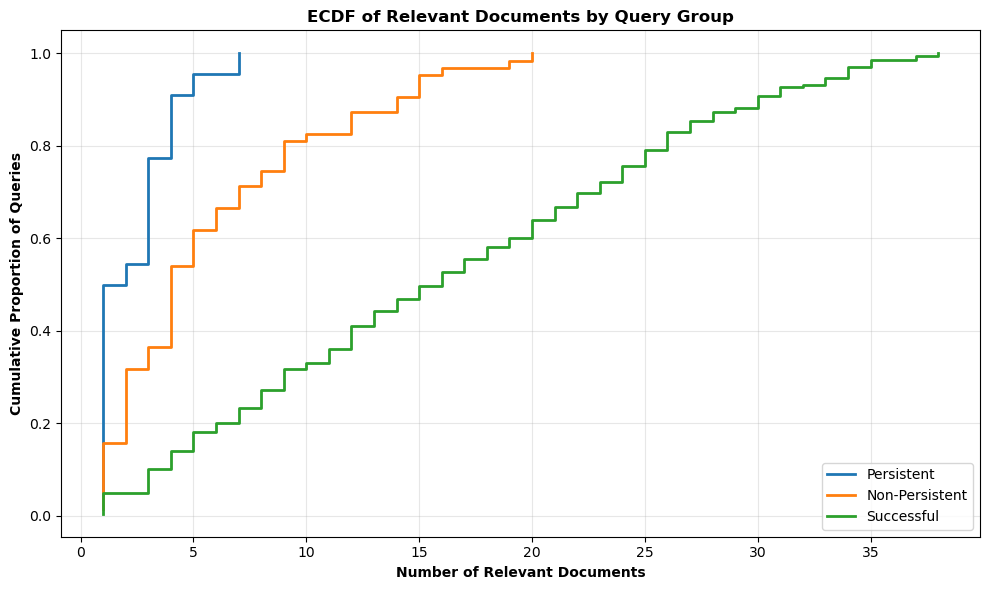

Saved: phase8_relevance_ecdf.png


In [16]:
print('\n'+'='*80)
print('RELEVANCE SPARSITY')
print('='*80)

persistent_data=reference_qm[reference_qm['qid'].isin(persistent_qids)]
non_persistent_data=reference_qm[reference_qm['qid'].isin(non_persistent_qids)]
successful_data=reference_qm[reference_qm['qid'].isin(successful_qids)]

def compute_sparsity(data: pd.DataFrame, group_name: str) -> dict:
    if len(data)==0:
        return {'group': group_name, 'count': 0, 'pct_num_rel_1': 0, 'pct_num_rel_lte_2': 0}
    total=len(data)
    return {
        'group': group_name,
        'count': total,
        #what % of queries in this group have exactly one relevant document
        'pct_num_rel_1': float(100 * (data['num_relevant_1'] == 1).sum() / total),
        #what % of queries in this group have very sparse relevance (1 or 2 relevant docs)
        'pct_num_rel_lte_2': float(100 * (data['num_relevant_1'] <= 2).sum() / total)
    }

sparsity_df=pd.DataFrame([
    compute_sparsity(persistent_data, 'persistent'),
    compute_sparsity(non_persistent_data, 'non_persistent'),
    compute_sparsity(successful_data, 'successful')
])

print('\nRelevance Sparsity:')
display(sparsity_df)

sparsity_df.to_csv(PHASE8_OUTPUT / 'phase8_relevance_sparsity.csv', index=False)
print('\nSaved: phase8_relevance_sparsity.csv')


# Empirical Cumulative Distribution Function (ECDF)

fig, ax = plt.subplots(figsize=(10, 6))

def plot_ecdf(values, label):
    if len(values)==0:
        return
    sorted_vals=np.sort(values)
    y=np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.step(sorted_vals, y, where='post', linewidth=2, label=label)

#Plotting ECDF for each group
plot_ecdf(persistent_data['num_relevant_1'].values, 'Persistent')
plot_ecdf(non_persistent_data['num_relevant_1'].values, 'Non-Persistent')
plot_ecdf(successful_data['num_relevant_1'].values, 'Successful')

ax.set_xlabel('Number of Relevant Documents', fontweight='bold')
ax.set_ylabel('Cumulative Proportion of Queries', fontweight='bold')
ax.set_title('ECDF of Relevant Documents by Query Group', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PHASE8_OUTPUT / 'phase8_relevance_ecdf.png', dpi=150)
plt.show()

print('Saved: phase8_relevance_ecdf.png')

The relevance sparsity results show a very clear structural separation between the three groups. Among persistent failures (22 queries), 50% have exactly one relevant document and 54.5% have at most two relevant documents. This means that more than half of the persistent queries are extremely sparse in terms of relevance. In contrast, only 15.9% of non-persistent failures have exactly one relevant document and 31.7% have at most two. The separation becomes even stronger for successful queries: only 4.9% have exactly one relevant document, and none have exactly two (since the percentage for ≤2 is also 4.9%).

This suggests that persistent failures are strongly associated with extreme relevance sparsity. These queries are not failing because they are larger (the number of documents per query was similar across groups earlier), but because they contain very few relevant documents, often just one. Successful queries, on the other hand, almost always have more than two relevant documents, making them structurally easier for ranking models. Overall, relevance sparsity appears to be a major structural characteristic distinguishing persistent failures from the other groups.

The ECDF reveals a clear structural separation between query groups. Persistent failures rise rapidly in the extreme low-relevance region: more than half have at most two relevant documents, whereas only 5% of successful queries fall into this area. The successful group extends far into high-relevance densities, while persistent failures are almost entirely constrained to low-relevance ranges. This indicates a strong association between extreme relevance sparsity and persistent ranking failure.

## 8. Score Separability (Gap)


SCORE SEPARABILITY (GAP ANALYSIS)

Score Gap Analysis:


,group,count,mean_gap,median_gap
0,persistent,22,-0.1722,-0.1557
1,non_persistent,63,0.0104,0.0000
2,successful,205,0.1428,0.1180



Saved: phase8_score_gap_analysis.csv


C:\Users\kusha\AppData\Local\Temp\ipykernel_8600\2653258510.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


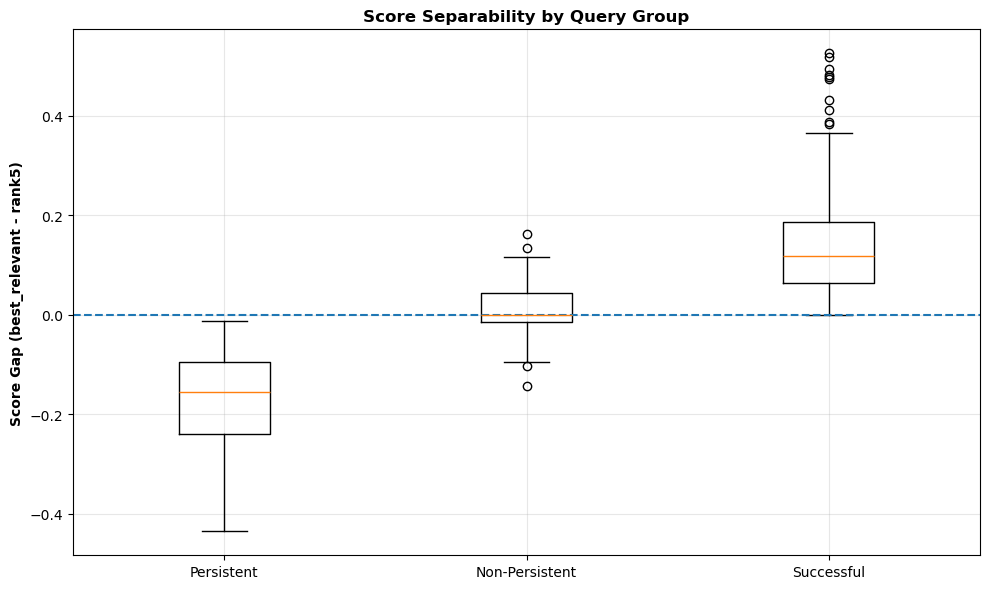

Saved: phase8_score_gap_boxplot.png


In [18]:
print('\n'+'='*80)
print('SCORE SEPARABILITY (GAP ANALYSIS)')
print('='*80)

def compute_gap(qid: int, pred_df: pd.DataFrame) -> float:
    #Computing gap=best_relevant_score-score_at_rank5. Returns np.nan if invalid.
    q_docs=pred_df[pred_df['qid']==qid].copy()
    if len(q_docs)==0:
        return np.nan
    q_docs=q_docs.sort_values('score', ascending=False).reset_index(drop=True)
    relevant=q_docs[q_docs['label']>=1]
    if len(relevant)==0:
        return np.nan
    best_rel_score=float(relevant['score'].max())
    k_actual=min(5, len(q_docs))
    if k_actual==0:
        return np.nan
    score_at_rank5=float(q_docs.iloc[k_actual-1]['score'])
    return best_rel_score-score_at_rank5

gaps={}
for qid in all_evaluable_qids:
    gaps[qid]=compute_gap(qid, reference_pred)

#Aggregating 
def aggregate_gaps(qids: set, group_name: str) -> dict:
    vals=[gaps[qid] for qid in qids if qid in gaps and not np.isnan(gaps[qid])]
    if len(vals)==0:
        return {'group': group_name, 'count': 0, 'mean_gap': np.nan, 'median_gap': np.nan}
    return {
        'group': group_name,
        'count': len(vals),
        'mean_gap': float(np.mean(vals)),
        'median_gap': float(np.median(vals))
    }

gap_df=pd.DataFrame([
    aggregate_gaps(persistent_qids, 'persistent'),
    aggregate_gaps(non_persistent_qids, 'non_persistent'),
    aggregate_gaps(successful_qids, 'successful')
])

print('\nScore Gap Analysis:')
display(gap_df)

gap_df.to_csv(PHASE8_OUTPUT / 'phase8_score_gap_analysis.csv', index=False)
print('\nSaved: phase8_score_gap_analysis.csv')

#Boxplot 
pers_gaps=[gaps[q] for q in persistent_qids if q in gaps and not np.isnan(gaps[q])]
nonp_gaps=[gaps[q] for q in non_persistent_qids if q in gaps and not np.isnan(gaps[q])]
succ_gaps=[gaps[q] for q in successful_qids if q in gaps and not np.isnan(gaps[q])]

fig, ax=plt.subplots(figsize=(10, 6))

data=[pers_gaps, nonp_gaps, succ_gaps]
labels=['Persistent', 'Non-Persistent', 'Successful']

ax.boxplot(data, labels=labels, showfliers=True)

#Vertical reference line at 0 (critical threshold)
ax.axhline(0, linestyle='--')

ax.set_ylabel('Score Gap (best_relevant - rank5)', fontweight='bold')
ax.set_title('Score Separability by Query Group', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PHASE8_OUTPUT / 'phase8_score_gap_boxplot.png', dpi=150)
plt.show()

print('Saved: phase8_score_gap_boxplot.png')

The score gap results show a very clear structural separation between the three query groups. For persistent failures, both the mean gap (-0.1722) and median gap (-0.1557) are negative. This means that, on average, the highest-scoring relevant document is actually scoring lower than the document at rank 5. In simple terms, the relevant document is not even close to breaking into the top-5 -- it is structurally pushed below the cutoff. This suggests that persistent failures are not random, but are strongly associated with poor score separability in the ranking system.



For non-persistent failures, the mean gap is very close to zero (0.0104) and the median is exactly 0. This indicates that these queries are mostly borderline cases. The best relevant document is often sitting right around the rank-5 boundary. Small changes in model or normalization can easily flip them from fail to success or vice versa. So these queries appear unstable rather than fundamentally broken.




In contrast, successful queries show clearly positive gaps (mean = 0.1428, median = 0.1180). This means that their best relevant documents are comfortably above the rank-5 cutoff, which makes it much easier for the model to rank them correctly.  



Overall, this analysis suggests that persistent failures are strongly associated with negative score gaps, meaning poor separability between relevant and non-relevant documents. Combined with the earlier relevance sparsity findings, it seems that persistent queries are both structurally sparse and also poorly separated in score space, which makes them consistently hard across all models.

The boxplot clearly shows a strong separation between the three query groups in terms of score gap. The dashed horizontal line at 0 represents the rank-5 cutoff boundary. Values above 0 mean the best relevant document is scoring higher than the score at rank 5, while values below 0 mean it is scoring lower and therefore likely outside the top-5.

For persistent queries, the entire box is below zero and the median is around −0.16. This means that for most persistent failures, the best relevant document is consistently ranked below the top-5 boundary. It is not just barely missing, but actually separated in the wrong direction. This suggests that persistent failures are strongly associated with poor score separability, where the model is not giving enough score advantage to relevant documents.

Non-persistent queries look very different. Their box is centered around zero and the median is almost exactly at the boundary. This shows that these queries are mostly borderline cases. The best relevant document is sitting very close to the cutoff, so small changes in model or normalization can easily flip them from failure to success or vice versa.

For successful queries, the box is clearly above zero and the median gap is positive (around 0.12). This means the best relevant documents are comfortably above the rank-5 cutoff. The model has clear separation in these cases, which makes it easier to rank them correctly.

Overall, the plot shows a clear structural gradient: persistent queries have negative separability, non-persistent queries are borderline, and successful queries have strong positive separability. This supports the idea that poor score separation at the rank-5 boundary is strongly associated with persistent ranking failure.

## 9. Loading Raw Test Features

In [19]:
print('\n'+'='*80)
print('LOADING RAW TEST FEATURES')
print('='*80)

test_file=DATA_RAW / 'MQ2007' / 'Fold1' / 'test.txt'
if not test_file.exists():
    raise RuntimeError(f'MISSING FILE: {test_file}')

data=[]
with open(test_file, 'r') as fh:
    for line in fh:
        if '#' in line:
            line=line[:line.index('#')]
        parts=line.strip().split()
        if len(parts)<2:
            continue
        label=int(parts[0])
        qid=int(parts[1].split(':')[1])
        feats={}
        for item in parts[2:]:
            if ':' in item:
                fid, fval=item.split(':', 1)
                fid=int(fid)
                if 1<=fid<=46:
                    feats[f'f{fid}']=float(fval)
        row={'qid': qid, 'label': label}
        row.update(feats)
        data.append(row)

test_2007=pd.DataFrame(data)

#Ensuring all f1..f46 present
for i in range(1, 47):
    if f'f{i}' not in test_2007.columns:
        test_2007[f'f{i}']=0.0

#Dropping zero-variance features (Phase 2 finding)
test_2007=test_2007.drop(columns=[f'f{i}' for i in range(6, 11)], errors='ignore')

feature_cols=[c for c in test_2007.columns if c.startswith('f')]

print(f'\nLoaded: {len(test_2007)} docs, {test_2007["qid"].nunique()} queries')
print(f'Features: {len(feature_cols)}')
print('='*80)


LOADING RAW TEST FEATURES

Loaded: 13652 docs, 336 queries
Features: 41


## 10. Feature Signal Comparison

In [20]:
print('\n'+'='*80)
print('FEATURE SIGNAL COMPARISON (Persistent vs Successful)')
print('='*80)

def compute_feature_stats(qids: set, test_df: pd.DataFrame, features: list, group_name: str):
    subset=test_df[test_df['qid'].isin(qids)]
    if len(subset)==0:
        return None
    rows=[]
    for feat in features:
        values=subset[feat].values
        #Within-query variance (ddof=0 explicit)
        wqv=[]
        for qid in qids:
            q_vals=test_df[test_df['qid']==qid][feat].values
            if len(q_vals)>1:
                wqv.append(np.var(q_vals, ddof=0))
        rows.append({
            'group': group_name,
            'feature': feat,
            'mean_value': float(values.mean()),
            'mean_within_query_var': float(np.mean(wqv)) if wqv else 0.0,
            'pct_zeros': float(100 * (values==0).sum() / len(values))
        })
    return pd.DataFrame(rows)

persistent_feat=compute_feature_stats(persistent_qids, test_2007, feature_cols, 'persistent')
successful_feat=compute_feature_stats(successful_qids, test_2007, feature_cols, 'successful')

if persistent_feat is not None and successful_feat is not None:
    feature_comparison=pd.concat([persistent_feat, successful_feat], ignore_index=True)
    #Deterministic sort
    feature_comparison=feature_comparison.sort_values(['feature', 'group'])
    feature_comparison.to_csv(PHASE8_OUTPUT / 'phase8_feature_signal_comparison.csv', index=False)
    print('\nSaved: phase8_feature_signal_comparison.csv')
    
    #Top 10 by variance difference
    pivot_var=feature_comparison.pivot(index='feature', columns='group', values='mean_within_query_var')
    pivot_var['diff']=abs(pivot_var['persistent']-pivot_var['successful'])
    print('\nTop 10 features by within-query variance difference:')
    display(pivot_var.nlargest(10, 'diff'))
else:
    print('\nInsufficient data for feature comparison')
    feature_comparison=None


FEATURE SIGNAL COMPARISON (Persistent vs Successful)

Saved: phase8_feature_signal_comparison.csv

Top 10 features by within-query variance difference:


group,persistent,successful,diff
feature,,,
f31,0.0895,0.1069,0.0174
f13,0.0815,0.0980,0.0165
f3,0.0812,0.0951,0.0139
f35,0.0398,0.0518,0.0119
f23,0.0724,0.0621,0.0103
f14,0.0665,0.0763,0.0098
f20,0.0583,0.0486,0.0097
f16,0.0584,0.0487,0.0097
f39,0.0695,0.0604,0.0091


This table is basically showing the top 10 features where the **within-query variance** differs the most between persistent failures and successful queries. Within-query variance is like, inside a single query, how much that feature values actually change across the documents. For many of these features (like f31, f13, f3, f35, f14, f30), the successful group has a higher within-query variance than the persistent group. That kind of suggests that in successful queries, these features give more "spread" or contrast between docs, so the model has a easier time separating and ranking them. In persistent queries, these same features look more flat, so relevant docs may not stand out much in feature space.  


There are also a few features (f23, f20, f16, f39) where persistent queries have higher within-query variance than successful ones. That could mean these features behave more noisily or inconsistently in the hard queries, but we can’t claim it for sure from just this table. Also the differences are not super huge (largest diff is around 0.017), so we're treating this more like a clue list for what features might matter, and we still need the statistical tests + effect sizes to confirm which of these differences are actually reliable.